# Script for testing regression version of CNN 

## Imports


In [22]:
import mne
import pickle 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold,GroupKFold
from sklearn.metrics import mean_absolute_error, accuracy_score, f1_score
import tensorflow as tf
from scipy.signal import resample_poly
from math import gcd
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
import gc

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
mne.set_log_level("CRITICAL")

## Loading in Data

In [283]:
features_all = pd.read_pickle("training_features_18042026.pkl")
features_all_temp = features_all
features_all = features_all[~((features_all["Subject"] == "RL03JG") & (features_all["Nap Number"] == 5))] # presentation for this subject is 0 ? somethign weird 

labels = pd.read_pickle("segments.pkl")

print("==========SANITY CHECK==========")
print("Nap IDs align? ", (labels["Nap_ID"].values == features_all["Nap Number"].values).all())
print("Subject rows align? ", (labels["Subject"].values == features_all["Subject"].values).all())

labels = labels.drop(columns=["Subject"])
features_all = features_all.reset_index(drop=True)
labels = labels.reset_index(drop=True)

features_all = pd.concat([features_all, labels], axis=1)  

==========SANITY CHECK==========
Nap IDs align?  True
Subject rows align?  True


In [106]:
# resample labels to match the features 
features_all["Contraction Corr"] = features_all["Contraction Corr"].apply(
    lambda x: resample_timeseries(x, orig_fs=2080, target_fs=250)
)

features_all["Contraction Zygo"] = features_all["Contraction Zygo"].apply(
    lambda x: resample_timeseries(x, orig_fs=2080, target_fs=250)
)

## Helper Functions 

In [105]:
# function for resampling time series data to sampling frequency of epochs 
def resample_timeseries(X, orig_fs, target_fs):

    g = gcd(orig_fs, target_fs)
    up   = target_fs // g   # upsample factor
    down = orig_fs   // g   # downsample factor

    resampled = resample_poly(X, up, down, axis=-1)

    # fix weirdness caused by resampling 
    resampled = (resampled >= 0.5).astype(int)[0:len(resampled)] 
    
    return resampled

In [74]:
def masked_mae(y_true, y_pred):
    y_true_pos = y_true[:, :-1]  # strip count column
    return tf.reduce_mean(tf.abs(y_pred - tf.cast(y_true_pos, tf.float32)))

In [75]:
# function for resampling time series data to sampling frequency of epochs 
def resample_timeseries(X, orig_fs, target_fs):

    g = gcd(orig_fs, target_fs)
    up   = target_fs // g   # upsample factor
    down = orig_fs   // g   # downsample factor

    resampled = resample_poly(X, up, down, axis=-1)

    # fix weirdness caused by resampling 
    resampled = (resampled >= 0.5).astype(int)[0:len(resampled)] 
    
    return resampled

In [85]:
def masked_mse_with_counts():
    def loss_fn(y_true, y_pred):
        counts_active = tf.cast(y_true[:, -1], tf.float32) * 2
        y_true_pos = y_true[:, :-1]

        max_len = tf.shape(y_true_pos)[1]
        range_row = tf.cast(tf.range(max_len), tf.float32)
        mask = range_row[tf.newaxis, :] < counts_active[:, tf.newaxis]

        squared_error = tf.square(y_pred - tf.cast(y_true_pos, tf.float32))
        masked_error = squared_error * tf.cast(mask, tf.float32)
        
        total_mask = tf.reduce_sum(tf.cast(mask, tf.float32))
        return tf.reduce_sum(masked_error) / tf.maximum(total_mask, 1.0)  # avoid div by zero
    return loss_fn

In [77]:
# returns sample points of contractions based on index in segmentationa array 
def find_contractions_indices(binary_labels):
    abinary_labelsrr = np.array(binary_labels)
    diff = np.diff(binary_labels, prepend=0, append=0)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    return starts, ends

In [241]:
def get_regression_labels_vectorized(arr, max_contractions=11):
    arr_binary = (arr > 0).astype(int)
    
    padded = np.concatenate([np.zeros((arr_binary.shape[0], 1)), arr_binary, np.zeros((arr_binary.shape[0], 1))], axis=1)
    diff = np.diff(padded, axis=1)

    result = np.full((arr.shape[0], max_contractions * 2), -1)
    
    for i in range(arr.shape[0]):
        starts = np.where(diff[i] == 1)[0]      # no offset needed
        ends = np.where(diff[i] == -1)[0] - 1   # -1 to get last sample of contraction
        
        # sanity check alignment
        if len(starts) != len(ends):
            print(f"Warning: sample {i} has {len(starts)} starts and {len(ends)} ends")
            continue
            
        n = min(len(starts), max_contractions)
        result[i, :n*2:2] = starts[:n]
        result[i, 1:n*2:2] = ends[:n]
    
    return result

In [79]:
def run_kfold_training(model_func,X_train_full, X, y, groups_train_full, input_shape, num_classes, feature_num,compile_kwargs,teacher_preds, fit_kwargs=None, # arguments fed to model.fit() 
                       n_splits=5,random_state=42, shuffle=True, verbose=1,epoch_num=10,
                         type=1,): # model type (1: single head count, 2: two head count and duration, 3: two head for zygo and corr, 4: four head) 
   # returns a dictionary with {"models", "histories", "cv_scores"}.     

    if fit_kwargs is None:
        fit_kwargs = {}
    fit_kwargs = fit_kwargs.copy()

 
    kf = GroupKFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    #kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    models = []
    histories = []
    cv_scores = []

    fold = 1
    for train_idx, val_idx in kf.split(X_train_full, groups=groups_train_full):
        print(f"Fold: {fold} {'='*65}")
        X_train, X_val = X[train_idx], X[val_idx]  # use X_train_full, not X
        y_train, y_val = y[train_idx], y[val_idx]

        model = model_func(input_shape, num_classes, feature_num)

        if type == 1:
            loss_fn = compile_kwargs.get("loss", "sparse_categorical_crossentropy")
        elif type == 2:
           # teacher_logits = teacher_preds[train_idx]
            loss_fn = masked_mse_with_counts()

        
        model.compile(
                optimizer=compile_kwargs["optimizer"],
                loss=loss_fn,
                metrics=compile_kwargs["metrics"]
            )

 
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=epoch_num,
        )

        scores = model.evaluate(X_val, y_val, return_dict=True)

        fold += 1
        models.append(model)
        histories.append(history)
        cv_scores.append(scores)

    return {
        "models": models,
        "histories": histories,
        "cv_scores": cv_scores,
    }

## CNN Model

In [81]:
# single head CNN model for number of contractions  
# single head CNN model for number of contractions  
def CNN_model_contraction_regression(input_shape, num_classes,feature_num):
    global epoch_len

    model = Sequential([
        Input(shape=(epoch_len, feature_num)) # NEED TO MAKE SHAPE A PARAMETER 
         # binary
    ])

    # Convolutional Layers - 
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))  # Add a 1D convolutional layer with 32 filters and ReLU activation
    model.add(MaxPooling1D(pool_size=2))  # Add a max pooling layer

    model.add(Conv1D(64, kernel_size=3, activation='relu'))  # Add another 1D convolutional layer with 64 filters and ReLU activation
    model.add(MaxPooling1D(pool_size=2))  # Add another max pooling layer

    #model.add(Conv1D(128, kernel_size=3, activation='relu'))  # Add another 1D convolutional layer?

    # Flattening Layer
    model.add(Flatten())  # Flatten the output of the convolutional layers


    # Fully Connected Layers - connect each neuron of one layer to other neuron 
    model.add(Dense(128, activation='relu')) # Add a fully connected layer with 128 neurons and ReLU activation
    model.add(Dropout(0.5)) # see if this changes anything? 
    model.add(Dense(num_classes, activation='linear'))  # Add the output layer with softmax activation


    return model  # Return the compiled model

In [15]:
# single head CNN model for number of contractions  
def CNN_model_contraction_events(input_shape, num_classes,feature_num):
    global epoch_len

    model = Sequential([
        Input(shape=(epoch_len, feature_num)) # NEED TO MAKE SHAPE A PARAMETER 
         # binary
    ])

    # Convolutional Layers - 
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))  # Add a 1D convolutional layer with 32 filters and ReLU activation
    model.add(MaxPooling1D(pool_size=2))  # Add a max pooling layer

    model.add(Conv1D(64, kernel_size=3, activation='relu'))  # Add another 1D convolutional layer with 64 filters and ReLU activation
    model.add(MaxPooling1D(pool_size=2))  # Add another max pooling layer

    #model.add(Conv1D(128, kernel_size=3, activation='relu'))  # Add another 1D convolutional layer?

    # Flattening Layer
    model.add(Flatten())  # Flatten the output of the convolutional layers


    # Fully Connected Layers - connect each neuron of one layer to other neuron 
    model.add(Dense(128, activation='relu')) # Add a fully connected layer with 128 neurons and ReLU activation
    model.add(Dropout(0.5)) # see if this changes anything? 
    model.add(Dense(num_classes, activation='softmax'))  # Add the output layer with softmax activation


    return model  # Return the compiled model

## Defining Training Data 

### Initializing Variables Needed

In [16]:
# global variables for training 
epoch_num = 10
patience = 6
early_stop = EarlyStopping(monitor='val_loss',  patience=patience, restore_best_weights=True)


metrics = ["f1", "accuracy", "mse"]
targets = ["zygo", "corr", "overall"]
splits = ["training", "testing"]
metric_tuples = [("model_name", "", "")]
metric_tuples += [
    (metric, target, split)
    for metric in metrics
    for target in targets
    for split in splits
]
metric_tuples += [("k-fold", "mean", ""), ("k-fold", "std", "")]
results_columns = pd.MultiIndex.from_tuples(
    metric_tuples,
    names=["metric", "target", "split"]
)
results_columns = pd.MultiIndex.from_tuples(metric_tuples)
results_df = pd.DataFrame(columns=results_columns)

### Training Data for Loss CNN

In [35]:
muscle_groups = features_all["True_Muscle_Activated"].repeat(2).reset_index(drop=True)

X_zygo = features_all[["Zygo"]] 
X_corr = features_all[["Corr"]]

X_zygo = X_zygo.to_numpy()
X_zygo = np.array(X_zygo.tolist())
X_zygo = np.transpose(X_zygo, (0, 2, 1)) # setting dimensions 

X_corr = X_corr.to_numpy()
X_corr = np.array(X_corr.tolist())
X_corr = np.transpose(X_corr, (0, 2, 1)) # setting dimensions 

X = np.concatenate((X_zygo, X_corr), axis=0)
y = np.concatenate([features_all["Num_Contractions_Zygo"].astype(int).to_numpy(),
                    features_all["Num_Contractions_Corr"].astype(int).to_numpy()])       

y_zygo = features_all["Num_Contractions_Zygo"].astype(int).to_numpy()
y_corr = features_all["Num_Contractions_Corr"].astype(int).to_numpy()


indices = np.arange(len(X))
idx_train, idx_test, muscle_train, muscle_test = train_test_split(indices, muscle_groups,test_size=0.2, random_state=42) # keep 20% purely for testing 

subjects_zygo = features_all["Subject"].to_numpy()  # adjust column name
subjects_corr = features_all["Subject"].to_numpy()
groups = np.concatenate([subjects_zygo, subjects_corr])  # mirrors how you built X and y

# Apply same train/test split to groups
groups_train_full = groups[idx_train]
groups_test = groups[idx_test]


# split like this to be able to recover the indices for later when rescoring 
X_train_full = X[idx_train]
X_test = X[idx_test]
y_train_full = y[idx_train]
y_test = y[idx_test]

input_shape = X_train_full.shape[1:]   
num_classes = len(np.unique(y))    

input_shape = (input_shape[0], 1)   
feature_num = np.shape(X_zygo)[2]
epoch_len = np.shape(X_zygo)[1]

### Training Data for Regression CNN

In [386]:
def sanity_check_regression_labels(y_events, y_events_labels, idx=None):
    if idx is None:
        idx = np.random.randint(0, len(y_events))
    
    signal = y_events[idx]
    labels = y_events_labels[idx]
    active_labels = labels[labels != -1]  # strip padding
    
    starts = active_labels[0::2].astype(int)  # every other starting from 0
    ends = active_labels[1::2].astype(int)    # every other starting from 1
 
    plt.figure(figsize=(15, 4))
    plt.plot(signal, label="signal", color="steelblue")
    plt.scatter(starts, signal[starts], color="green", zorder=5, label="start", marker="^", s=100)
    plt.scatter(ends, signal[ends], color="red", zorder=5, label="end", marker="v", s=100)
    plt.title(f"Sample {idx} — {len(starts)} contraction(s) detected")
    plt.legend()
    
    plt.tight_layout()
    

In [367]:
y_zygo = features_all[["Contraction Zygo"]].to_numpy()
y_corr = features_all[["Contraction Corr"]].to_numpy()

y_zygo = np.array(y_zygo.tolist())
y_corr = np.array(y_corr.tolist())
y_events = np.concatenate((y_zygo, y_corr), axis=0)    

y_events = y_events.squeeze(1)  # (N, epoch_len, 1) -> (N, epoch_len)  
y_events_labels = get_regression_labels_vectorized(y_events)

resample_ratio = 250 / 2048

# rescale active indices only (leave -1 padding unchanged)
y_events_labels_resampled = y_events_labels.astype(float).copy()
mask = y_events_labels != -1
y_events_labels_resampled[mask] = np.round(y_events_labels[mask] * resample_ratio).astype(int)


y_events_labels_normalized = y_events_labels_resampled.copy().astype(float)
mask = y_events_labels_normalized != -1
y_events_labels_normalized[mask] = y_events_labels_normalized[mask] / epoch_len  # scale to [0,1]

# no normalization 
true_counts = (y_events_labels != -1).sum(axis=1) // 2          # (N,) — number of contractions per sample
y_events_labels_with_counts = np.concatenate([y_events_labels_normalized, true_counts[:, np.newaxis]], axis=1 )      # (N, 23) — 22 positions + 1 count


y_train_full_events = y_events_labels_with_counts[idx_train]
y_test_events = y_events_labels_with_counts[idx_test]

num_classes = np.shape(y_events_labels)[1]    # should be 22


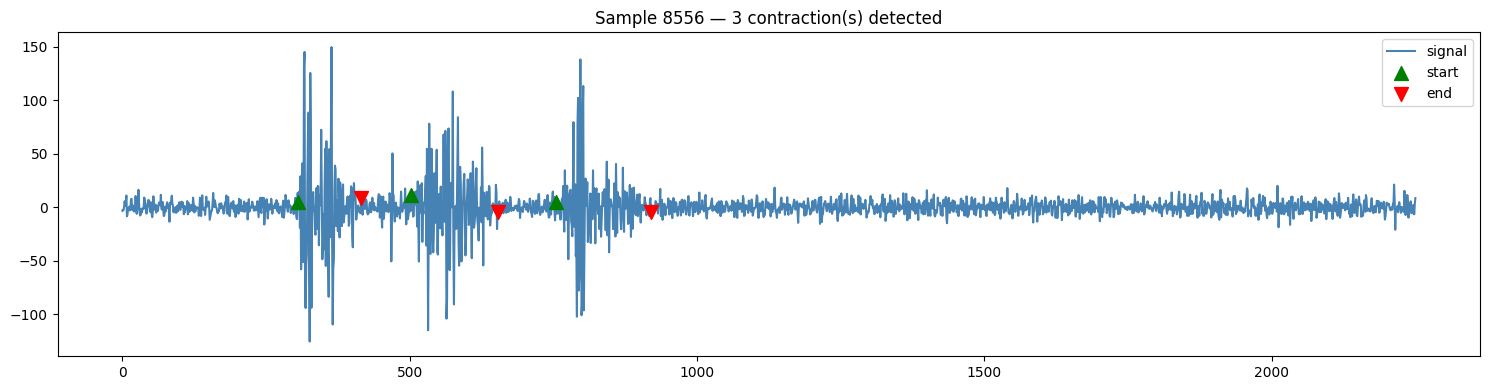

In [359]:
sanity_check_regression_labels(X,y_events_labels_resampled) # y_events y_events_labels

## Training Model

In [ ]:
compile_kwargs={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "metrics": ["accuracy"]
    }

model = CNN_model_contraction_events(input_shape, num_classes, feature_num)

optimizer=compile_kwargs["optimizer"],
loss=compile_kwargs["loss"],
metrics=compile_kwargs["metrics"]

model.compile(
                optimizer=compile_kwargs["optimizer"],
                loss=loss,
                metrics=compile_kwargs["metrics"]
            )

model_history_contraction = model.fit(X_train_full, y_train_full, epochs=epoch_num, validation_data=(X_test, y_test)) #, callbacks=[early_stop])

In [ ]:
# call function for training
results_single_head_contraction = run_kfold_training(
    model_func=CNN_model_contraction_events,
    X_train_full=X_train_full,
    X=X,
    y=y,
    groups_train_full=groups_train_full,
    teacher_preds=None,
    input_shape=input_shape,
    num_classes=num_classes,
    feature_num=feature_num,
    compile_kwargs={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "metrics": ["accuracy"]
    },
    fit_kwargs={"epochs": 10},
    n_splits=5,
    type=1,)


model_contraction = results_single_head_contraction["models"][-1]
model_history_contraction = model_contraction.fit(X_train_full, y_train_full, epochs=epoch_num, validation_data=(X_test, y_test)) #, callbacks=[early_stop])

In [55]:
# full training results (test data not seen during cross val)
y_pred_train = model.predict(X_train_full)  
y_pred_train = np.argmax(y_pred_train, axis=1)   

# Predict on test data
y_pred_test = model.predict(X_test)   
y_pred_test = np.argmax(y_pred_test, axis=1)   

# Calculate accuracy
accuracy_training = accuracy_score(y_train_full, y_pred_train)   
accuracy_test = accuracy_score(y_test, y_pred_test)  

# Calculate F1 score
f1_training = f1_score(y_train_full, y_pred_train, average='weighted')  
f1_test = f1_score(y_test, y_pred_test, average='weighted')  

# Print accuracy and F1 score
print("Model scores---------------")
print("Training Accuracy :", accuracy_training)  
print("Test Accuracy :", accuracy_test)  
print("Training F1 Score :", f1_training)   
print("Test F1 Score :", f1_test) 

  7/357 [..............................] - ETA: 2s  

2026-06-03 11:09:40.763923: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


90/90 [==============================] - 1s 5ms/step
Model scores---------------
Training Accuracy : 0.928921568627451
Test Accuracy : 0.9166666666666666
Training F1 Score : 0.9165589851104146
Test F1 Score : 0.9015864586934248


In [ ]:
#with open('model_contraction_og.pkl', 'wb') as f:
#    pickle.dump(model_contraction, f)

## Training Regression

In [54]:
with open("model_contraction_og2.pkl", "rb") as file:
    model = pickle.load(file)

2026-06-03 11:09:33.107305: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-06-03 11:09:33.108332: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-03 11:09:33.108630: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-06-03 11:09:33.109669: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-03 11:09:33.110743: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [369]:
# = model.predict(X_train_full)

# call function for training
results_single_head_regression = run_kfold_training(
    model_func=CNN_model_contraction_regression,
    X_train_full=X_train_full,
    X=X,
    y=y_events_labels_with_counts,
    teacher_preds= None,
    groups_train_full=groups_train_full,
    input_shape=input_shape,
    num_classes=num_classes,
    feature_num=feature_num,
    compile_kwargs={
        "optimizer": tf.keras.optimizers.legacy.Adam(learning_rate=1e-4, clipnorm=1.0),
        "loss": "sparse_categorical_crossentropy",
        "metrics": [masked_mae]
    },
    fit_kwargs={"epochs": 10},
    n_splits=5,
    type=2)


model_regression_final = results_single_head_regression["models"][-1]
model_history_regression = model_regression_final.fit(X_train_full, y_train_full_events, epochs=epoch_num, validation_data=(X_test, y_test_events)) #, callbacks=[early_stop])

Fold: 1 =================================================================
Epoch 1/10
282/282 [==============================] - 9s 29ms/step - loss: 437.0190 - masked_mae: 7.9475 - val_loss: 32.1753 - val_masked_mae: 4.6578
Epoch 2/10
282/282 [==============================] - 7s 23ms/step - loss: 448.6875 - masked_mae: 7.9217 - val_loss: 19.1082 - val_masked_mae: 3.8408
Epoch 3/10
282/282 [==============================] - 8s 28ms/step - loss: 340.0828 - masked_mae: 6.5695 - val_loss: 10.3294 - val_masked_mae: 2.6466
Epoch 4/10
282/282 [==============================] - 7s 25ms/step - loss: 253.3866 - masked_mae: 5.8698 - val_loss: 6.6341 - val_masked_mae: 2.4232
Epoch 5/10
282/282 [==============================] - 7s 25ms/step - loss: 153.1072 - masked_mae: 4.8648 - val_loss: 3.2096 - val_masked_mae: 2.1479
Epoch 6/10
282/282 [==============================] - 9s 31ms/step - loss: 95.2478 - masked_mae: 3.8916 - val_loss: 1.5949 - val_masked_mae: 1.7606
Epoch 7/10
282/282 [==========

In [380]:
preds_normalized = model_regression_final.predict(X_test)  # (N, 22), values in [0,1]

# denormalize
preds = np.clip(preds_normalized, 0, 1) * epoch_len  # clip before denormalizing
preds = np.round(preds).astype(int)
preds = np.where(preds >= epoch_len, 0, preds)

90/90 [==============================] - 1s 7ms/step


In [381]:
preds[0]

array([ 661,  632,  642,  675,  798,  886, 1828,  580,    0, 2189,    0,
        992,    0,    0,    0,    0,    0,    0,    0,    0,    0, 1262])

(-200.0, 200.0)

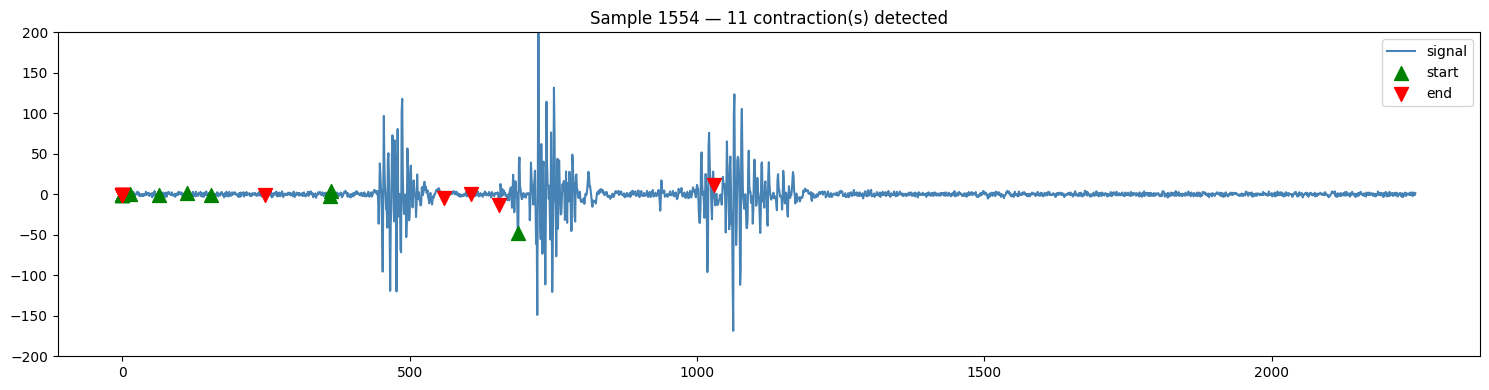

In [388]:
sanity_check_regression_labels(X_test,preds) # y_events y_events_labels
plt.ylim(-200,200)

In [376]:
np.shape(X)

(14280, 2251, 1)

In [97]:
print(y_events_labels_normalized[y_events_labels_normalized != -1/epoch_len].min())
print(y_events_labels_normalized[y_events_labels_normalized != -1/epoch_len].max())

-1.0
9.098178587294536
